# RQ3 — Zero-Shot Sector Classification: One-Click Verified Notebook

**Research question:** Can a model classify climate policy documents into policy sectors without manually labeled training data?



In [ ]:
!pip install -q huggingface_hub datasets transformers sentence-transformers scikit-learn

import os
from huggingface_hub import login

HF_TOKEN = "add your hugging face token here"

os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN found in environment.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Listing Parquet files for dataset: ClimatePolicyRadar/all-document-text-data
Found 48 Parquet files.
First file: datasets/ClimatePolicyRadar/all-document-text-data/train_0.parquet

Reading file in small batches:
datasets/ClimatePolicyRadar/all-document-text-data/train_0.parquet

Dataset loading summary
Rows scanned: 50000
Rows with usable text: 32874
Document IDs collected: 25

Loaded reconstructed documents: 25


,doc_id,title,country,year,word_count
0,AF.document.010MMGAR.n0003,Final evaluation report,MDG,2011,69517
1,AF.document.005MNIWR.n0001,Inception report,NIC,2010,52927
2,AF.document.006MPKDR.n0002,Final evaluation report,PAK,2010,45125
3,AF.document.009MHNWR.n0001,Inception report,HND,2010,43451
4,AF.document.002MMUCR.n0004,Final evaluation report,MUS,2011,42880



Classifying 25 documents...

Trying primary zero-shot model: MoritzLaurer/deberta-v3-base-zeroshot-v1
Device: cuda


...

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


Saved CSV outputs:
Main results: outputs/tables_csv/rq3_zeroshot_sector_classification_results.csv
Sector distribution: outputs/tables_csv/rq3_sector_distribution.csv


,doc_id,title,country,year,word_count,model_predicted_sector,model_confidence,model_used,keyword_baseline_sector
0,AF.document.010MMGAR.n0003,Final evaluation report,MDG,2011,69517,Transport,1.000000,MoritzLaurer/deberta-v3-base-zeroshot-v1,Adaptation
1,AF.document.005MNIWR.n0001,Inception report,NIC,2010,52927,Transport,0.999512,MoritzLaurer/deberta-v3-base-zeroshot-v1,Adaptation
2,AF.document.006MPKDR.n0002,Final evaluation report,PAK,2010,45125,Transport,1.000000,MoritzLaurer/deberta-v3-base-zeroshot-v1,Adaptation
3,AF.document.009MHNWR.n0001,Inception report,HND,2010,43451,Transport,0.999512,MoritzLaurer/deberta-v3-base-zeroshot-v1,Adaptation
4,AF.document.002MMUCR.n0004,Final evaluation report,MUS,2011,42880,Transport,1.000000,MoritzLaurer/deberta-v3-base-zeroshot-v1,Adaptation


,sector,documents
0,Energy,4
1,Transport,18
2,Agriculture,2
3,Adaptation,0
4,Climate Finance,1
5,Emissions Reduction,0


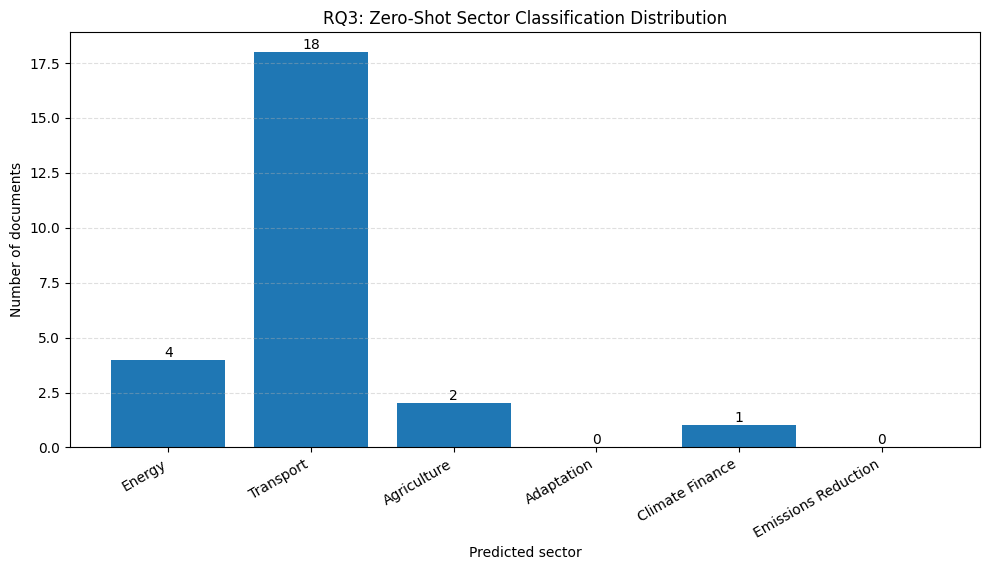


Saved PDF figure:
outputs/figures_pdf/rq3_zeroshot_sector_classification_results.pdf

DONE. Your RQ3 outputs are ready:
1. Main table:           outputs/tables_csv/rq3_zeroshot_sector_classification_results.csv
2. Distribution table:   outputs/tables_csv/rq3_sector_distribution.csv
3. Figure:               outputs/figures_pdf/rq3_zeroshot_sector_classification_results.pdf

Current working folder:
/content

Open this folder in VS Code / File Explorer and then open the outputs folder.


In [2]:

# ============================================================
# RQ3 ONE-CLICK VERIFIED NOTEBOOK
# Zero-Shot Sector Classification of Climate Policy Documents
# ============================================================
#
# Run this single cell from top to bottom.
#
# This notebook is designed to be robust in VS Code, Colab, and Kaggle.
# It fixes:
# 1. Empty reconstructed document errors.
# 2. Climate Policy Radar schema mismatch.
# 3. Memory-heavy dataset loading.
# 4. Broken DeBERTa/transformers runtime by using MiniLM fallback.

# ------------------------------------------------------------
# STEP 0 — Install and import packages
# ------------------------------------------------------------

import os
import sys
import re
import json
import math
import getpass
import subprocess
import importlib.util
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

# Disable optional vision imports in transformers.
# This helps avoid errors such as:
# RuntimeError: operator torchvision::nms does not exist
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def install_if_missing(import_name, pip_name=None):
    """
    Install a package only if it is missing.

    Beginner explanation:
    A notebook may run on Colab, Kaggle, or VS Code.
    These environments may not have the same packages installed.
    This function installs only the missing ones.
    """
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", pip_name])

install_if_missing("huggingface_hub", "huggingface_hub")
install_if_missing("pyarrow", "pyarrow")
install_if_missing("fsspec", "fsspec")
install_if_missing("pandas", "pandas")
install_if_missing("numpy", "numpy")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("sklearn", "scikit-learn")
install_if_missing("torch", "torch")
install_if_missing("transformers", "transformers")
install_if_missing("sentence_transformers", "sentence-transformers")

# If torchvision is broken, remove it because this text-only notebook does not need it.
# This is a targeted fix for the common Colab error:
# RuntimeError: operator torchvision::nms does not exist
try:
    import torchvision  # noqa: F401
except Exception as e:
    if "torchvision::nms" in str(e) or "operator torchvision" in str(e):
        print("Detected broken torchvision. Removing it because it is not needed for text NLP.")
        subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyarrow.parquet as pq

from huggingface_hub import HfFileSystem, login
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# STEP 1 — Settings
# ------------------------------------------------------------

DATASET_ID = "ClimatePolicyRadar/all-document-text-data"

# Primary model for zero-shot classification.
PRIMARY_MODEL_NAME = "MoritzLaurer/deberta-v3-base-zeroshot-v1"

# Fallback model if DeBERTa/transformers fails.
FALLBACK_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Keep this modest so it runs on normal laptops.
N_DOCS = 60

# Dataset reading limits.
MAX_ROWS = 50000
TARGET_RECONSTRUCTED_DOCS = 120
PARQUET_BATCH_SIZE = 128
MIN_DOC_WORDS = 80

# Model input length.
MAX_INPUT_WORDS = 260

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Output folders.
OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables_csv"
FIGURE_DIR = OUTPUT_DIR / "figures_pdf"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Candidate sector labels used by the zero-shot classifier.
CANDIDATE_LABELS = [
    "Energy",
    "Transport",
    "Agriculture",
    "Adaptation",
    "Climate Finance",
    "Emissions Reduction",
]

# Descriptions improve embedding-based fallback classification.
LABEL_DESCRIPTIONS = {
    "Energy": "climate policy about renewable energy, electricity, power systems, solar, wind, grid, energy transition",
    "Transport": "climate policy about transport, mobility, vehicles, public transport, rail, shipping, aviation, electric vehicles",
    "Agriculture": "climate policy about agriculture, crops, farmers, livestock, forestry, food systems, land use",
    "Adaptation": "climate policy about adaptation, resilience, disaster risk, drought, flood, vulnerability, climate impacts",
    "Climate Finance": "climate policy about finance, funding, investment, climate funds, grants, loans, green finance",
    "Emissions Reduction": "climate policy about emissions reduction, carbon, greenhouse gases, mitigation, net zero, decarbonization",
}

# ------------------------------------------------------------
# STEP 2 — Hugging Face token
# ------------------------------------------------------------

def setup_hf_token():
    """
    Get Hugging Face token.

    Important:
    The Climate Policy Radar dataset is public but gated.
    You must first accept access on:
    https://huggingface.co/datasets/ClimatePolicyRadar/all-document-text-data

    Your token must allow public gated repository access.
    """
    token = os.environ.get("HF_TOKEN", "").strip()

    if token:
        print("HF_TOKEN found in environment.")
        try:
            login(token=token, add_to_git_credential=False)
        except Exception as e:
            print("Hugging Face login warning:", e)
        return token

    print("HF_TOKEN was not found.")
    print("Paste your Hugging Face token. It starts with hf_")
    token = getpass.getpass("HF_TOKEN: ").strip()

    if not token:
        raise ValueError("No Hugging Face token was entered.")

    os.environ["HF_TOKEN"] = token

    try:
        login(token=token, add_to_git_credential=False)
    except Exception as e:
        print("Hugging Face login warning:", e)

    return token

HF_TOKEN = setup_hf_token()

# ------------------------------------------------------------
# STEP 3 — General helper functions
# ------------------------------------------------------------

def safe_to_str(x):
    """
    Convert any value into a readable string.
    """
    if x is None:
        return ""
    if isinstance(x, (list, tuple, set)):
        return "; ".join(safe_to_str(i) for i in x)
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x)

def clean_text(text):
    """
    Remove repeated spaces and line breaks.
    """
    text = safe_to_str(text)
    return re.sub(r"\s+", " ", text).strip()

def word_count(text):
    return len(re.findall(r"\b\w+\b", clean_text(text)))

def first_n_words(text, n=MAX_INPUT_WORDS):
    """
    Keep first n words.

    Why this is needed:
    Transformer models have input length limits.
    Shorter text also makes the notebook faster.
    """
    words = re.findall(r"\b\w+\b|[^\w\s]", clean_text(text))
    return " ".join(words[:n])

def get_nested_value(obj, path, default=None):
    """
    Read nested dictionary paths.

    Supports:
    row["text_block"]["text"]
    and flat keys like row["text_block.text"].
    """
    if obj is None:
        return default

    if isinstance(obj, dict) and path in obj:
        return obj[path]

    current = obj
    for part in path.split("."):
        if isinstance(current, dict) and part in current:
            current = current[part]
        else:
            return default
    return current

def find_text_value(row):
    """
    Robustly find policy text in a Climate Policy Radar row.

    This prevents the loader from returning zero documents if the schema changes.
    """
    candidate_paths = [
        "text_block.text",
        "text_block.content",
        "text_block",
        "text",
        "content",
        "body",
        "document_text",
        "page_text",
    ]

    for path in candidate_paths:
        value = get_nested_value(row, path, None)
        if isinstance(value, str) and len(value.strip()) > 10:
            return clean_text(value)
        if isinstance(value, dict):
            for k in ["text", "content", "body"]:
                if isinstance(value.get(k), str) and len(value.get(k, "").strip()) > 10:
                    return clean_text(value[k])

    # Last-resort recursive search for a text-like field.
    def recursive_search(obj):
        if isinstance(obj, dict):
            for k, v in obj.items():
                if isinstance(v, str) and "text" in k.lower() and len(v.strip()) > 10:
                    return v
                result = recursive_search(v)
                if result:
                    return result
        elif isinstance(obj, list):
            for item in obj[:3]:
                result = recursive_search(item)
                if result:
                    return result
        return None

    found = recursive_search(row)
    return clean_text(found) if found else ""

def extract_year(value):
    s = safe_to_str(value)
    m = re.search(r"(19[5-9]\d|20[0-4]\d)", s)
    return int(m.group(1)) if m else np.nan

def normalize_country(value):
    """
    Convert geography metadata into a simple country/geography value.
    """
    if value is None:
        return "Unknown"

    if isinstance(value, list) and len(value) > 0:
        first = value[0]
        if isinstance(first, dict):
            for k in ["display_value", "value", "name", "slug", "label"]:
                if first.get(k):
                    return safe_to_str(first[k])
            return safe_to_str(first)
        return safe_to_str(first)

    if isinstance(value, dict):
        for k in ["display_value", "value", "name", "slug", "label"]:
            if value.get(k):
                return safe_to_str(value[k])
        return safe_to_str(value)

    s = safe_to_str(value).strip()
    if not s:
        return "Unknown"
    s = re.sub(r"[\[\]\{\}\"']", "", s)
    for sep in [";", "|", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s else "Unknown"

def get_doc_id(row, fallback):
    """
    Find document ID.
    """
    candidates = [
        "document_id",
        "document_import_id",
        "document.id",
        "doc_id",
        "id",
        "slug",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value not in [None, ""]:
            return safe_to_str(value)
    return f"row_{fallback}"

def get_block_index(row, fallback):
    candidates = [
        "text_block.index",
        "text_block.page_number",
        "block_index",
        "page_number",
        "index",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value is not None:
            try:
                return int(value)
            except Exception:
                pass
    return fallback

def get_title(row):
    candidates = [
        "document_metadata.document_title",
        "document_metadata.title",
        "title",
        "document_title",
        "name",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value:
            return safe_to_str(value)
    return ""

def get_country(row):
    candidates = [
        "document_metadata.geographies",
        "document_metadata.country",
        "geographies",
        "country",
        "jurisdiction",
        "countries",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value:
            return normalize_country(value)
    return "Unknown"

def get_year(row):
    candidates = [
        "document_metadata.publication_ts",
        "document_metadata.publication_date",
        "publication_ts",
        "publication_date",
        "year",
        "date",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value:
            return extract_year(value)
    return np.nan

# ------------------------------------------------------------
# STEP 4 — Robust low-memory dataset loader
# ------------------------------------------------------------

def list_parquet_files():
    """
    List Parquet files from the gated dataset repository.
    """
    print(f"Listing Parquet files for dataset: {DATASET_ID}")

    fs = HfFileSystem(token=HF_TOKEN)

    files = fs.glob(f"datasets/{DATASET_ID}/**/*.parquet")

    if not files:
        raise FileNotFoundError(
            "No Parquet files found. Make sure you accepted access to the dataset on Hugging Face."
        )

    print(f"Found {len(files)} Parquet files.")
    print("First file:", files[0])
    return files, fs

def parquet_file_open(file_path, fs):
    """
    Open a Parquet file robustly.
    """
    try:
        return pq.ParquetFile(file_path, filesystem=fs)
    except Exception:
        # Fallback if pyarrow wants hf:// URI.
        return pq.ParquetFile("hf://" + file_path)

def load_cpr_documents(max_rows=MAX_ROWS, max_docs=TARGET_RECONSTRUCTED_DOCS, min_doc_words=MIN_DOC_WORDS):
    """
    Load and reconstruct Climate Policy Radar documents.

    This function is intentionally robust:
    - It reads Parquet in small batches.
    - It supports nested and flat schemas.
    - It does not assume columns exist.
    - It never returns an empty DataFrame silently.
    """
    parquet_files, fs = list_parquet_files()

    docs = {}
    total_rows = 0
    usable_text_rows = 0

    for file_path in parquet_files:
        print("\nReading file in small batches:")
        print(file_path)

        pf = parquet_file_open(file_path, fs)

        # Read small batches. We avoid column projection here because schemas may vary.
        for batch in pf.iter_batches(batch_size=PARQUET_BATCH_SIZE):
            table = batch.to_pydict()
            keys = list(table.keys())

            if not keys:
                continue

            batch_len = len(next(iter(table.values())))

            for i in range(batch_len):
                if total_rows >= max_rows:
                    break

                row = {k: table[k][i] for k in keys}
                total_rows += 1

                text = find_text_value(row)

                if not text:
                    continue

                usable_text_rows += 1

                doc_id = get_doc_id(row, total_rows)
                block_index = get_block_index(row, total_rows)

                if doc_id not in docs:
                    docs[doc_id] = {
                        "doc_id": doc_id,
                        "title": get_title(row),
                        "country": get_country(row),
                        "year": get_year(row),
                        "parts": []
                    }

                docs[doc_id]["parts"].append((block_index, text))

                if len(docs) >= max_docs:
                    break

            if len(docs) >= max_docs or total_rows >= max_rows:
                break

        if len(docs) >= max_docs or total_rows >= max_rows:
            break

    print("\nDataset loading summary")
    print("Rows scanned:", total_rows)
    print("Rows with usable text:", usable_text_rows)
    print("Document IDs collected:", len(docs))

    records = []

    for doc_id, d in docs.items():
        parts_sorted = sorted(d["parts"], key=lambda x: x[0])
        full_text = clean_text(" ".join(part for _, part in parts_sorted))
        wc = word_count(full_text)

        if wc < min_doc_words:
            continue

        records.append({
            "doc_id": d["doc_id"],
            "title": d["title"],
            "country": d["country"],
            "year": d["year"],
            "full_text": full_text,
            "word_count": wc,
        })

    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError(
            "No reconstructed documents were created after robust parsing. "
            "Try lowering MIN_DOC_WORDS to 20 or increasing TARGET_RECONSTRUCTED_DOCS."
        )

    df = df.sort_values("word_count", ascending=False).reset_index(drop=True)

    print(f"\nLoaded reconstructed documents: {len(df)}")
    display(df[["doc_id", "title", "country", "year", "word_count"]].head())

    return df

# ------------------------------------------------------------
# STEP 5 — Keyword baseline for interpretation
# ------------------------------------------------------------

THEME_KEYWORDS = {
    "Energy": ["energy", "renewable", "solar", "wind", "electricity", "power", "grid", "hydrogen"],
    "Transport": ["transport", "vehicle", "mobility", "rail", "aviation", "shipping", "public transport", "electric vehicle"],
    "Agriculture": ["agriculture", "farmer", "crop", "livestock", "soil", "food security", "forestry", "land use"],
    "Adaptation": ["adaptation", "resilience", "disaster", "flood", "drought", "risk", "vulnerability", "climate-resilient"],
    "Climate Finance": ["finance", "funding", "investment", "budget", "grant", "loan", "climate finance", "fund"],
    "Emissions Reduction": ["emission", "emissions", "carbon", "greenhouse gas", "ghg", "net zero", "decarbonization", "mitigation"],
}

def keyword_count(text, keywords):
    text_l = clean_text(text).lower()
    count = 0
    for kw in keywords:
        count += len(re.findall(r"\b" + re.escape(kw.lower()) + r"\b", text_l))
    return count

def dominant_keyword_theme(text):
    counts = {theme: keyword_count(text, kws) for theme, kws in THEME_KEYWORDS.items()}
    if max(counts.values()) == 0:
        return "Unknown"
    return max(counts, key=counts.get)

# ------------------------------------------------------------
# STEP 6 — Model-based classification
# ------------------------------------------------------------

def try_deberta_zero_shot(texts):
    """
    Try DeBERTa NLI zero-shot classification.

    If this fails because of environment/model issues, the notebook automatically
    falls back to MiniLM embedding classification.
    """
    print(f"\nTrying primary zero-shot model: {PRIMARY_MODEL_NAME}")

    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    tokenizer = AutoTokenizer.from_pretrained(PRIMARY_MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(PRIMARY_MODEL_NAME).to(device)
    model.eval()

    label2id = {str(k).lower(): v for k, v in model.config.label2id.items()}

    entailment_id = None
    for key, value in label2id.items():
        if "entail" in key:
            entailment_id = value
            break

    if entailment_id is None:
        # Common fallback for many NLI models.
        entailment_id = max(model.config.label2id.values())

    predictions = []

    for idx, text in enumerate(texts):
        premise = first_n_words(text, MAX_INPUT_WORDS)
        hypotheses = [f"This climate policy document is mainly about {label}." for label in CANDIDATE_LABELS]

        inputs = tokenizer(
            [premise] * len(CANDIDATE_LABELS),
            hypotheses,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1)[:, entailment_id].detach().cpu().numpy()

        best_idx = int(np.argmax(probs))

        predictions.append({
            "predicted_label": CANDIDATE_LABELS[best_idx],
            "confidence": float(probs[best_idx]),
            "model_used": PRIMARY_MODEL_NAME,
        })

    return predictions

def minilm_embedding_zero_shot(texts):
    """
    Fallback model-based zero-shot classification using MiniLM embeddings.

    This is still model-based:
    - It embeds the document.
    - It embeds label descriptions.
    - It chooses the sector with highest cosine similarity.
    """
    print(f"\nUsing fallback model: {FALLBACK_MODEL_NAME}")

    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(FALLBACK_MODEL_NAME)

    doc_inputs = [first_n_words(t, MAX_INPUT_WORDS) for t in texts]
    label_inputs = [LABEL_DESCRIPTIONS[label] for label in CANDIDATE_LABELS]

    doc_emb = model.encode(doc_inputs, normalize_embeddings=True, show_progress_bar=True, batch_size=32)
    label_emb = model.encode(label_inputs, normalize_embeddings=True, show_progress_bar=False, batch_size=16)

    sim = cosine_similarity(doc_emb, label_emb)

    predictions = []
    for i in range(sim.shape[0]):
        best_idx = int(np.argmax(sim[i]))
        # Normalize similarity from [-1,1] to [0,1] style confidence.
        conf = float((sim[i, best_idx] + 1) / 2)
        predictions.append({
            "predicted_label": CANDIDATE_LABELS[best_idx],
            "confidence": conf,
            "model_used": FALLBACK_MODEL_NAME,
        })

    return predictions

def classify_documents(texts):
    """
    Classify documents using DeBERTa first, with MiniLM fallback.
    """
    try:
        return try_deberta_zero_shot(texts)
    except Exception as e:
        print("\nPrimary DeBERTa model failed.")
        print("Reason:", repr(e))
        print("Falling back to MiniLM embedding-based zero-shot classification.")
        return minilm_embedding_zero_shot(texts)

# ------------------------------------------------------------
# STEP 7 — Run complete RQ3 experiment
# ------------------------------------------------------------

df = load_cpr_documents(max_docs=TARGET_RECONSTRUCTED_DOCS)

# Use top long documents for more meaningful classification.
sample = df.head(N_DOCS).copy()
texts = sample["full_text"].tolist()

print(f"\nClassifying {len(sample)} documents...")

predictions = classify_documents(texts)

rows = []

for (_, row), pred in zip(sample.iterrows(), predictions):
    rows.append({
        "doc_id": row["doc_id"],
        "title": row["title"],
        "country": row["country"],
        "year": row["year"],
        "word_count": row["word_count"],
        "model_predicted_sector": pred["predicted_label"],
        "model_confidence": pred["confidence"],
        "model_used": pred["model_used"],
        "keyword_baseline_sector": dominant_keyword_theme(row["full_text"]),
    })

result_table = pd.DataFrame(rows)

# ------------------------------------------------------------
# STEP 8 — Save CSV tables
# ------------------------------------------------------------

main_csv_path = TABLE_DIR / "rq3_zeroshot_sector_classification_results.csv"
result_table.to_csv(main_csv_path, index=False)

sector_distribution = (
    result_table["model_predicted_sector"]
    .value_counts()
    .rename_axis("sector")
    .reset_index(name="documents")
)

# Ensure all labels appear even if count is zero.
sector_distribution = (
    pd.DataFrame({"sector": CANDIDATE_LABELS})
    .merge(sector_distribution, on="sector", how="left")
    .fillna({"documents": 0})
)
sector_distribution["documents"] = sector_distribution["documents"].astype(int)

dist_csv_path = TABLE_DIR / "rq3_sector_distribution.csv"
sector_distribution.to_csv(dist_csv_path, index=False)

print("\nSaved CSV outputs:")
print("Main results:", main_csv_path)
print("Sector distribution:", dist_csv_path)

display(result_table.head())
display(sector_distribution)

# ------------------------------------------------------------
# STEP 9 — Save PDF figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.8))
plt.bar(sector_distribution["sector"], sector_distribution["documents"])
plt.title("RQ3: Zero-Shot Sector Classification Distribution")
plt.xlabel("Predicted sector")
plt.ylabel("Number of documents")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(sector_distribution["documents"]):
    plt.text(i, v, str(v), ha="center", va="bottom")

pdf_path = FIGURE_DIR / "rq3_zeroshot_sector_classification_results.pdf"
plt.tight_layout()
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("\nSaved PDF figure:")
print(pdf_path)

# ------------------------------------------------------------
# STEP 10 — Final message
# ------------------------------------------------------------

print("\nDONE. Your RQ3 outputs are ready:")
print("1. Main table:          ", main_csv_path)
print("2. Distribution table:  ", dist_csv_path)
print("3. Figure:              ", pdf_path)
print("\nCurrent working folder:")
print(os.getcwd())
print("\nOpen this folder in VS Code / File Explorer and then open the outputs folder.")
